# Punto 2 
*ETAPA 2 - Modelo Forecast TCRM*

## Objetivo

Construir un modelo de series temporales para estimar la TCRM del 1 de enero de 2023 utilizando el histórico disponible.

In [1]:
# ==========================================
# Librerías
# ==========================================

import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

In [14]:
# ==========================================
# Cargar histórico diario
# ==========================================

tcrm = pd.read_excel(
    "../data/processed/tcrm_historico.xlsx"
)

tcrm.head()

,fecha,valor
0,1991-12-02,643.42
1,1991-12-03,639.22
2,1991-12-04,635.70
3,1991-12-05,631.51
4,1991-12-06,627.16


In [15]:
# ==========================================
# Preparación serie temporal
# ==========================================

tcrm["fecha"] = pd.to_datetime(tcrm["fecha"])

tcrm = tcrm.sort_values("fecha")

tcrm = tcrm.set_index("fecha")

serie = tcrm["valor"]

serie.head()

fecha
1991-12-02    643.42
1991-12-03    639.22
1991-12-04    635.70
1991-12-05    631.51
1991-12-06    627.16
Name: valor, dtype: float64

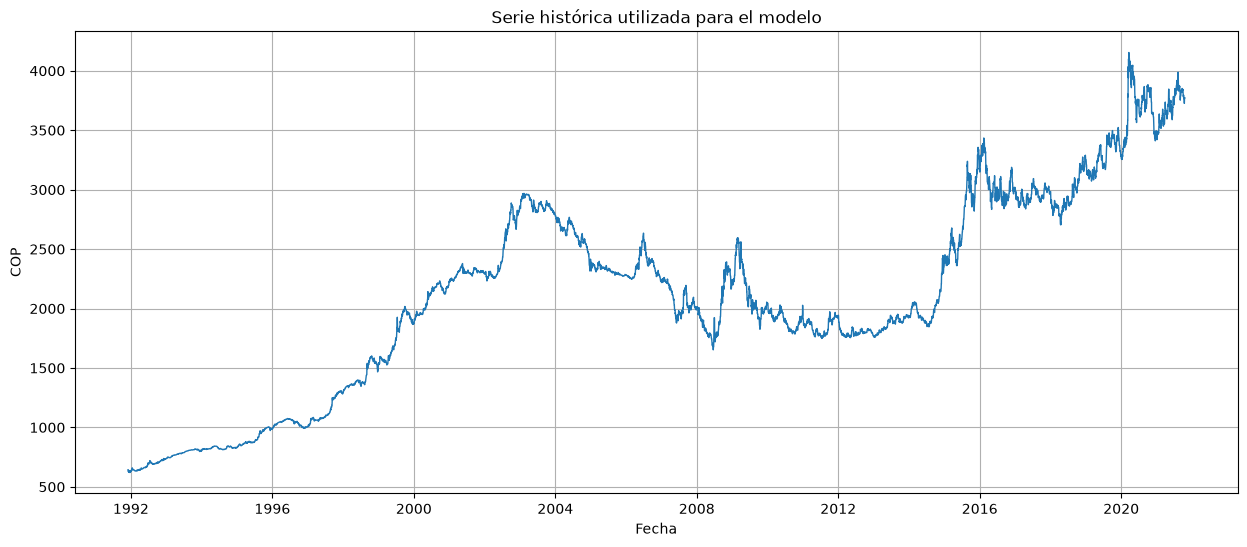

In [16]:
# ==========================================
# Serie utilizada
# ==========================================

plt.figure(figsize=(15,6))

plt.plot(
    serie,
    linewidth=1
)

plt.title("Serie histórica utilizada para el modelo")

plt.xlabel("Fecha")

plt.ylabel("COP")

plt.grid(True)

plt.show()

In [17]:
# ==========================================
# Modelo SARIMA
# ==========================================

modelo = SARIMAX(

    serie,

    order=(1,1,1),

    seasonal_order=(1,1,1,12),

    enforce_stationarity=False,

    enforce_invertibility=False

)

resultado = modelo.fit()

In [19]:
# ==========================================
# Cantidad de días a pronosticar
# ==========================================

fecha_final = serie.index.max()

fecha_objetivo = pd.Timestamp("2023-01-01")

dias = (fecha_objetivo - fecha_final).days

print(dias)

439


In [20]:
# ==========================================
# Forecast
# ==========================================

forecast = resultado.get_forecast(steps=dias)

predicciones = forecast.predicted_mean

intervalos = forecast.conf_int()

In [21]:
# ==========================================
# TCRM estimada
# ==========================================

tcrm_2023 = predicciones.iloc[-1]

print(f"TCRM estimada: ${tcrm_2023:,.2f}")

TCRM estimada: $3,897.69


In [22]:
# ==========================================
# Desviación estándar estimada
# ==========================================

desv_std = np.sqrt(forecast.var_pred_mean.iloc[-1])

print(f"Desviación estándar estimada: {desv_std:,.2f}")

Desviación estándar estimada: 308.48


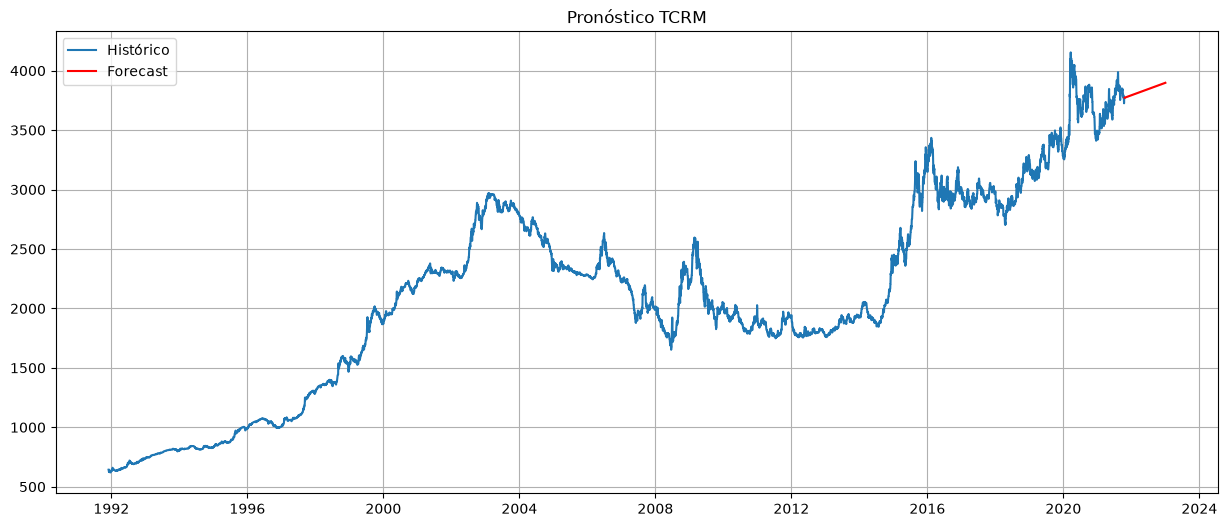

In [23]:
# ==========================================
# Visualización forecast
# ==========================================

plt.figure(figsize=(15,6))

plt.plot(

    serie,

    label="Histórico"

)

plt.plot(

    predicciones,

    color="red",

    label="Forecast"

)

plt.legend()

plt.grid(True)

plt.title("Pronóstico TCRM")

plt.show()

# Interpretación del modelo

Se implementó un modelo SARIMA para pronosticar la Tasa de Cambio
Representativa del Mercado (TCRM) utilizando el comportamiento histórico
de la serie temporal.

La elección de este modelo se debe a que SARIMA es uno de los métodos
más utilizados para pronóstico de series temporales, ya que incorpora la
dependencia temporal entre observaciones y permite capturar tendencias y
patrones presentes en la información histórica sin requerir variables
externas.

Resultados obtenidos

• TCRM estimada para el 01 de enero de 2023:
  $3,897.69 COP

• Desviación estándar estimada:
  308.48 COP

El pronóstico mantiene la tendencia creciente observada durante los
últimos años del histórico y proyecta una TCRM cercana a los niveles
alcanzados al finalizar el periodo de entrenamiento.

La desviación estándar representa la incertidumbre asociada al
pronóstico. En una serie financiera es normal que exista variabilidad,
por lo que el resultado debe interpretarse como una estimación dentro
de un rango probable y no como un valor exacto.